In [25]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from cdo import Cdo
import tempfile
import xesmf as xe
import regridding_oceanfiles as rg

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44561 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44561/status,
Dashboard: http://127.0.0.1:44561/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33445,Workers: 0
Dashboard: http://127.0.0.1:44561/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38961,Total threads: 4
Dashboard: http://127.0.0.1:44227/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:44377,


Task exception was never retrieved
future: <Task finished name='Task-70313' coro=<Client._gather.<locals>.wait() done, defined at /nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/client.py:2377> exception=AllExit()>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/client.py", line 2386, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-113269' coro=<Client._gather.<locals>.wait() done, defined at /nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/client.py:2377> exception=AllExit()>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/client.py", line 2386, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-314927' coro=<Client._gath

In [4]:
path_ocn = "/projects/NS1004K/elihho/NHIST_tropochem_250916/ocn/hist"
ds = xr.open_mfdataset(f"{path_ocn}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.blom.hm.*.nc", combine="by_coords")

"""
path_ocn_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/ocn/hist"
ds_KeyClim = xr.open_mfdataset(f"{path_ocn_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.blom.hm.*.nc", combine="by_coords")
ds_KeyClim = ds_KeyClim.sel(time=slice("1975-01-01", "2014-12-31"))
"""

'\npath_ocn_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/ocn/hist"\nds_KeyClim = xr.open_mfdataset(f"{path_ocn_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.blom.hm.*.nc", combine="by_coords")\nds_KeyClim = ds_KeyClim.sel(time=slice("1975-01-01", "2014-12-31"))\n'

In [5]:
#client.close()

In [6]:
ds

<xarray.Dataset> Size: 365GB
Dimensions:     (time: 240, depth: 70, bounds: 2, y: 385, x: 360, sigma: 53,
                 region: 4, lat: 171, section: 17)
Coordinates:
  * time        (time) object 2kB 1975-01-17 00:00:00 ... 1994-12-17 00:00:00
  * sigma       (sigma) float64 424B 27.22 27.72 28.2 28.68 ... 37.48 37.58 37.8
  * depth       (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * lat         (lat) float64 1kB -80.0 -79.0 -78.0 -77.0 ... 88.0 89.0 90.0
  * region      (region) |S50 200B b'atlantic_arctic_ocean                   ...
  * section     (section) |S50 850B b'barents_opening                        ...
Dimensions without coordinates: bounds, y, x
Data variables: (12/112)
    depth_bnds  (time, depth, bounds) float64 269kB dask.array<chunksize=(1, 70, 2), meta=np.ndarray>
    sigmx       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    ubaro       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    vbaro       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    psrf        (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    pbot        (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    ...          ...
    tempga      (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    sssga       (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    sstga       (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    dp_trc      (time, sigma, y, x) float32 7GB dask.array<chunksize=(1, 53, 385, 360), meta=np.ndarray>
    idlage      (time, sigma, y, x) float32 7GB dask.array<chunksize=(1, 53, 385, 360), meta=np.ndarray>
    idlagelvl   (time, depth, y, x) float32 9GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>

In [26]:
var = "sst"
modelversion = "NorESM2"
dr = rg.regrid_ocean(ds[var], var, modelversion, "/projects/NS1004K/elihho/NHIST_ocean_regridded")

In regrid_file


/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Regridding maker made
Regridding completed


In [27]:
dr

<xarray.Dataset> Size: 53MB
Dimensions:  (time: 240, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 2kB 1975-01-17 00:00:00 ... 1994-12-17 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    sst      (time, lat, lon) float32 53MB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>

### SST and ENSO phase

In [29]:
sst_1991 = dr.sel(time=slice("1991-01", "1991-12"))
baseline = dr.groupby("time.month").mean("time")            # baseline = the whole dataset mean
sst_anom = sst_1991.groupby("time.month") - baseline

sst_anom_dec = sst_anom.mean(dim="time")
pacific = sst_anom_dec.sel(lon=slice(120, 290), lat =slice(-35, 35))

In [30]:
pacific

<xarray.Dataset> Size: 42kB
Dimensions:  (lat: 74, lon: 137)
Coordinates:
  * lat      (lat) float64 592B -34.4 -33.46 -32.51 -31.57 ... 32.51 33.46 34.4
  * lon      (lon) float64 1kB 120.0 121.2 122.5 123.8 ... 287.5 288.8 290.0
Data variables:
    sst      (lat, lon) float32 41kB dask.array<chunksize=(74, 137), meta=np.ndarray>

KeyboardInterrupt: 

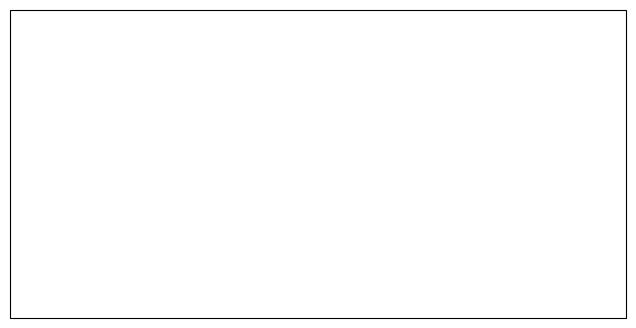

In [34]:
plt.figure(figsize=(12,4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
pcm = pacific['sst'].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-3, vmax=3,
    add_colorbar=True
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Pacific SST anomalies 1991")
plt.show()

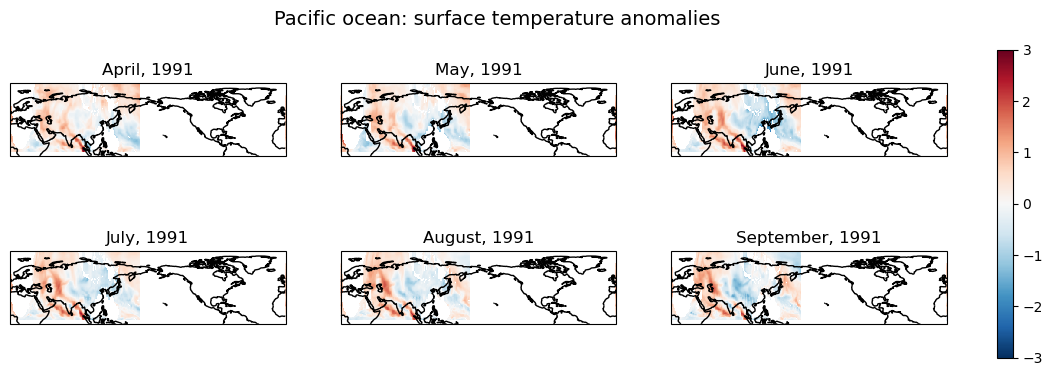

In [ ]:
months_eruption = [4, 5, 6, 7, 8, 9]                                    # april, may, june, july, august, september
nino_lat_min, nino_lat_max = -5, 5
nino_lon_min, nino_lon_max = 190, 240

fig, axes = plt.subplots(2, 3, figsize=(13, 4),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    sharex=True, sharey=True
)
axes = axes.flatten()

for ax, month in zip(axes, months_eruption):
    sst_month = sst_anom.sel(time=sst_anom["time.month"] == month)
    sst_month_mean = sst_month.mean(dim="time")
    pacific_month = sst_month_mean.sel(lon=slice(120, 290), lat =slice(-35, 35))

    pcm = pacific_month.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"{calendar.month_name[month]}, 1991")

    rect = Rectangle(
        (nino_lon_min, nino_lat_min),
        nino_lon_max - nino_lon_min,
        nino_lat_max - nino_lat_min,
        facecolor='none',
        edgecolor='black',
        linewidth=1.5,
        linestyle='--',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)


fig.suptitle("Pacific ocean: surface temperature anomalies", fontsize=14)
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.02)
plt.show()

In [ ]:
baseline = dr.groupby("time.month").mean("time")
sst_anom = dr.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

KeyError: "'lon' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 240, 'y': 385, 'x': 360})"

### Ocean temperature

In [ ]:
temp = "temp"          # Ocean temperature, degC
ocn_temp = ds[temp]